In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Fix for the 'CatBoostClassifier' object has no attribute '__sklearn_tags__' error
if not hasattr(CatBoostClassifier, '__sklearn_tags__'):
    def __sklearn_tags__(self):
        return {"classifier_only": True, "requires_fit": True, "X_types": ["2darray", "pandas"], "allow_nan": True}
    CatBoostClassifier.__sklearn_tags__ = __sklearn_tags__

In [3]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

#train_df['sex_pain_type'] = train_df['Sex'].astype(str) + "_" + train_df['Chest pain type'].astype(str)
#test_df['sex_pain_type'] = test_df['Sex'].astype(str) + "_" + test_df['Chest pain type'].astype(str)

#test_df['st_angina_interaction'] = test_df['ST depression'] * test_df['Exercise angina']
#train_df['st_angina_interaction'] = train_df['ST depression'] * train_df['Exercise angina']

# Convert the Target ('Presence'/'Absence') into 1 and 0
# Machine learning models require numbers, not text.
le = LabelEncoder()
target = 'Heart Disease'
train_df[target] = le.fit_transform(train_df[target])

# Separate features from the label
X = train_df.drop(columns=['id', target])
y = train_df[target]
X_test = test_df.drop(columns=['id'])

In [4]:

# Load data
train = pd.read_csv('train.csv')

# 1. Integrity Check
print("--- Dataset Overview ---")
print(train.info())
print("\n--- Missing Values ---")
print(train.isnull().sum())

# 2. Statistical Summary
print("\n--- Numerical Feature Statistics ---")
display(train.describe().T)
import seaborn as sns
print(sns.__version__)

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 no

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,54.136706,8.256301,29.0,48.00,54.0,60.00,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.00,1.0,1.00,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.00,4.0,4.00,4.0
BP,630000.0,130.497433,14.975802,94.0,120.00,130.0,140.00,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.00,243.0,269.00,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.00,0.0,0.00,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.00,0.0,2.00,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.00,157.0,166.00,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.00,0.0,1.00,1.0


0.13.2


In [5]:
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


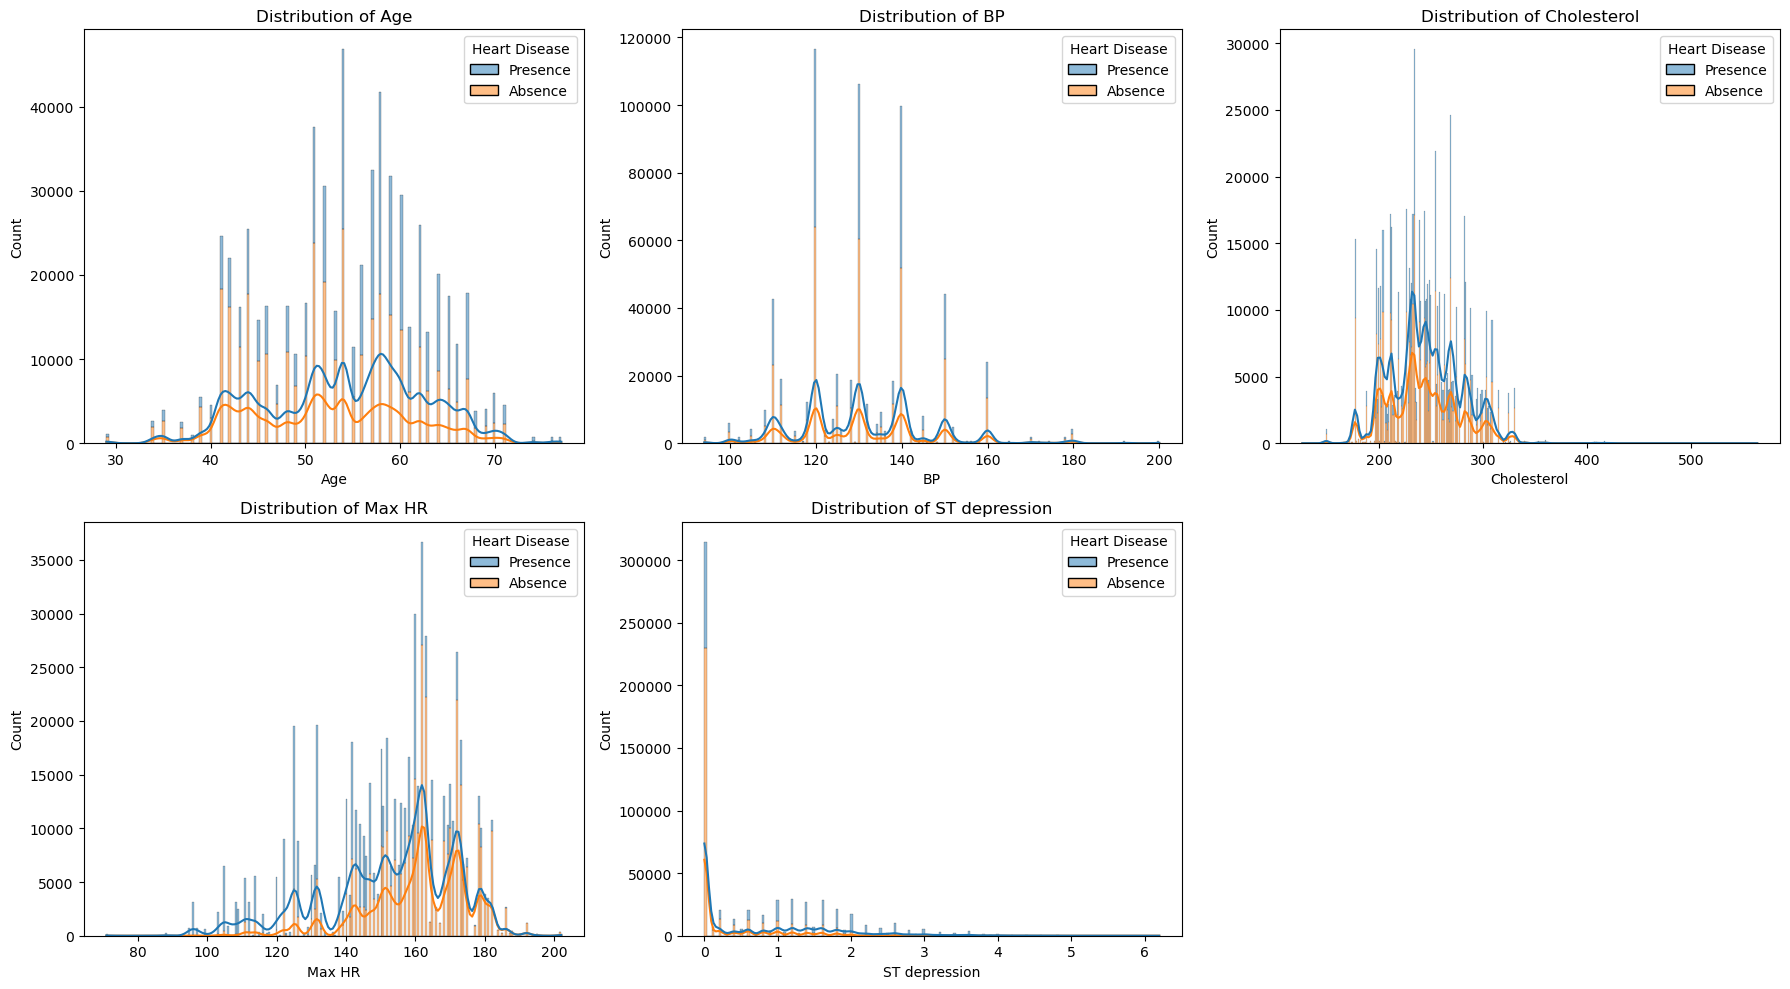

In [44]:
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, hue='Heart Disease', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[5]) # Remove the extra empty plot
plt.tight_layout()
plt.show()


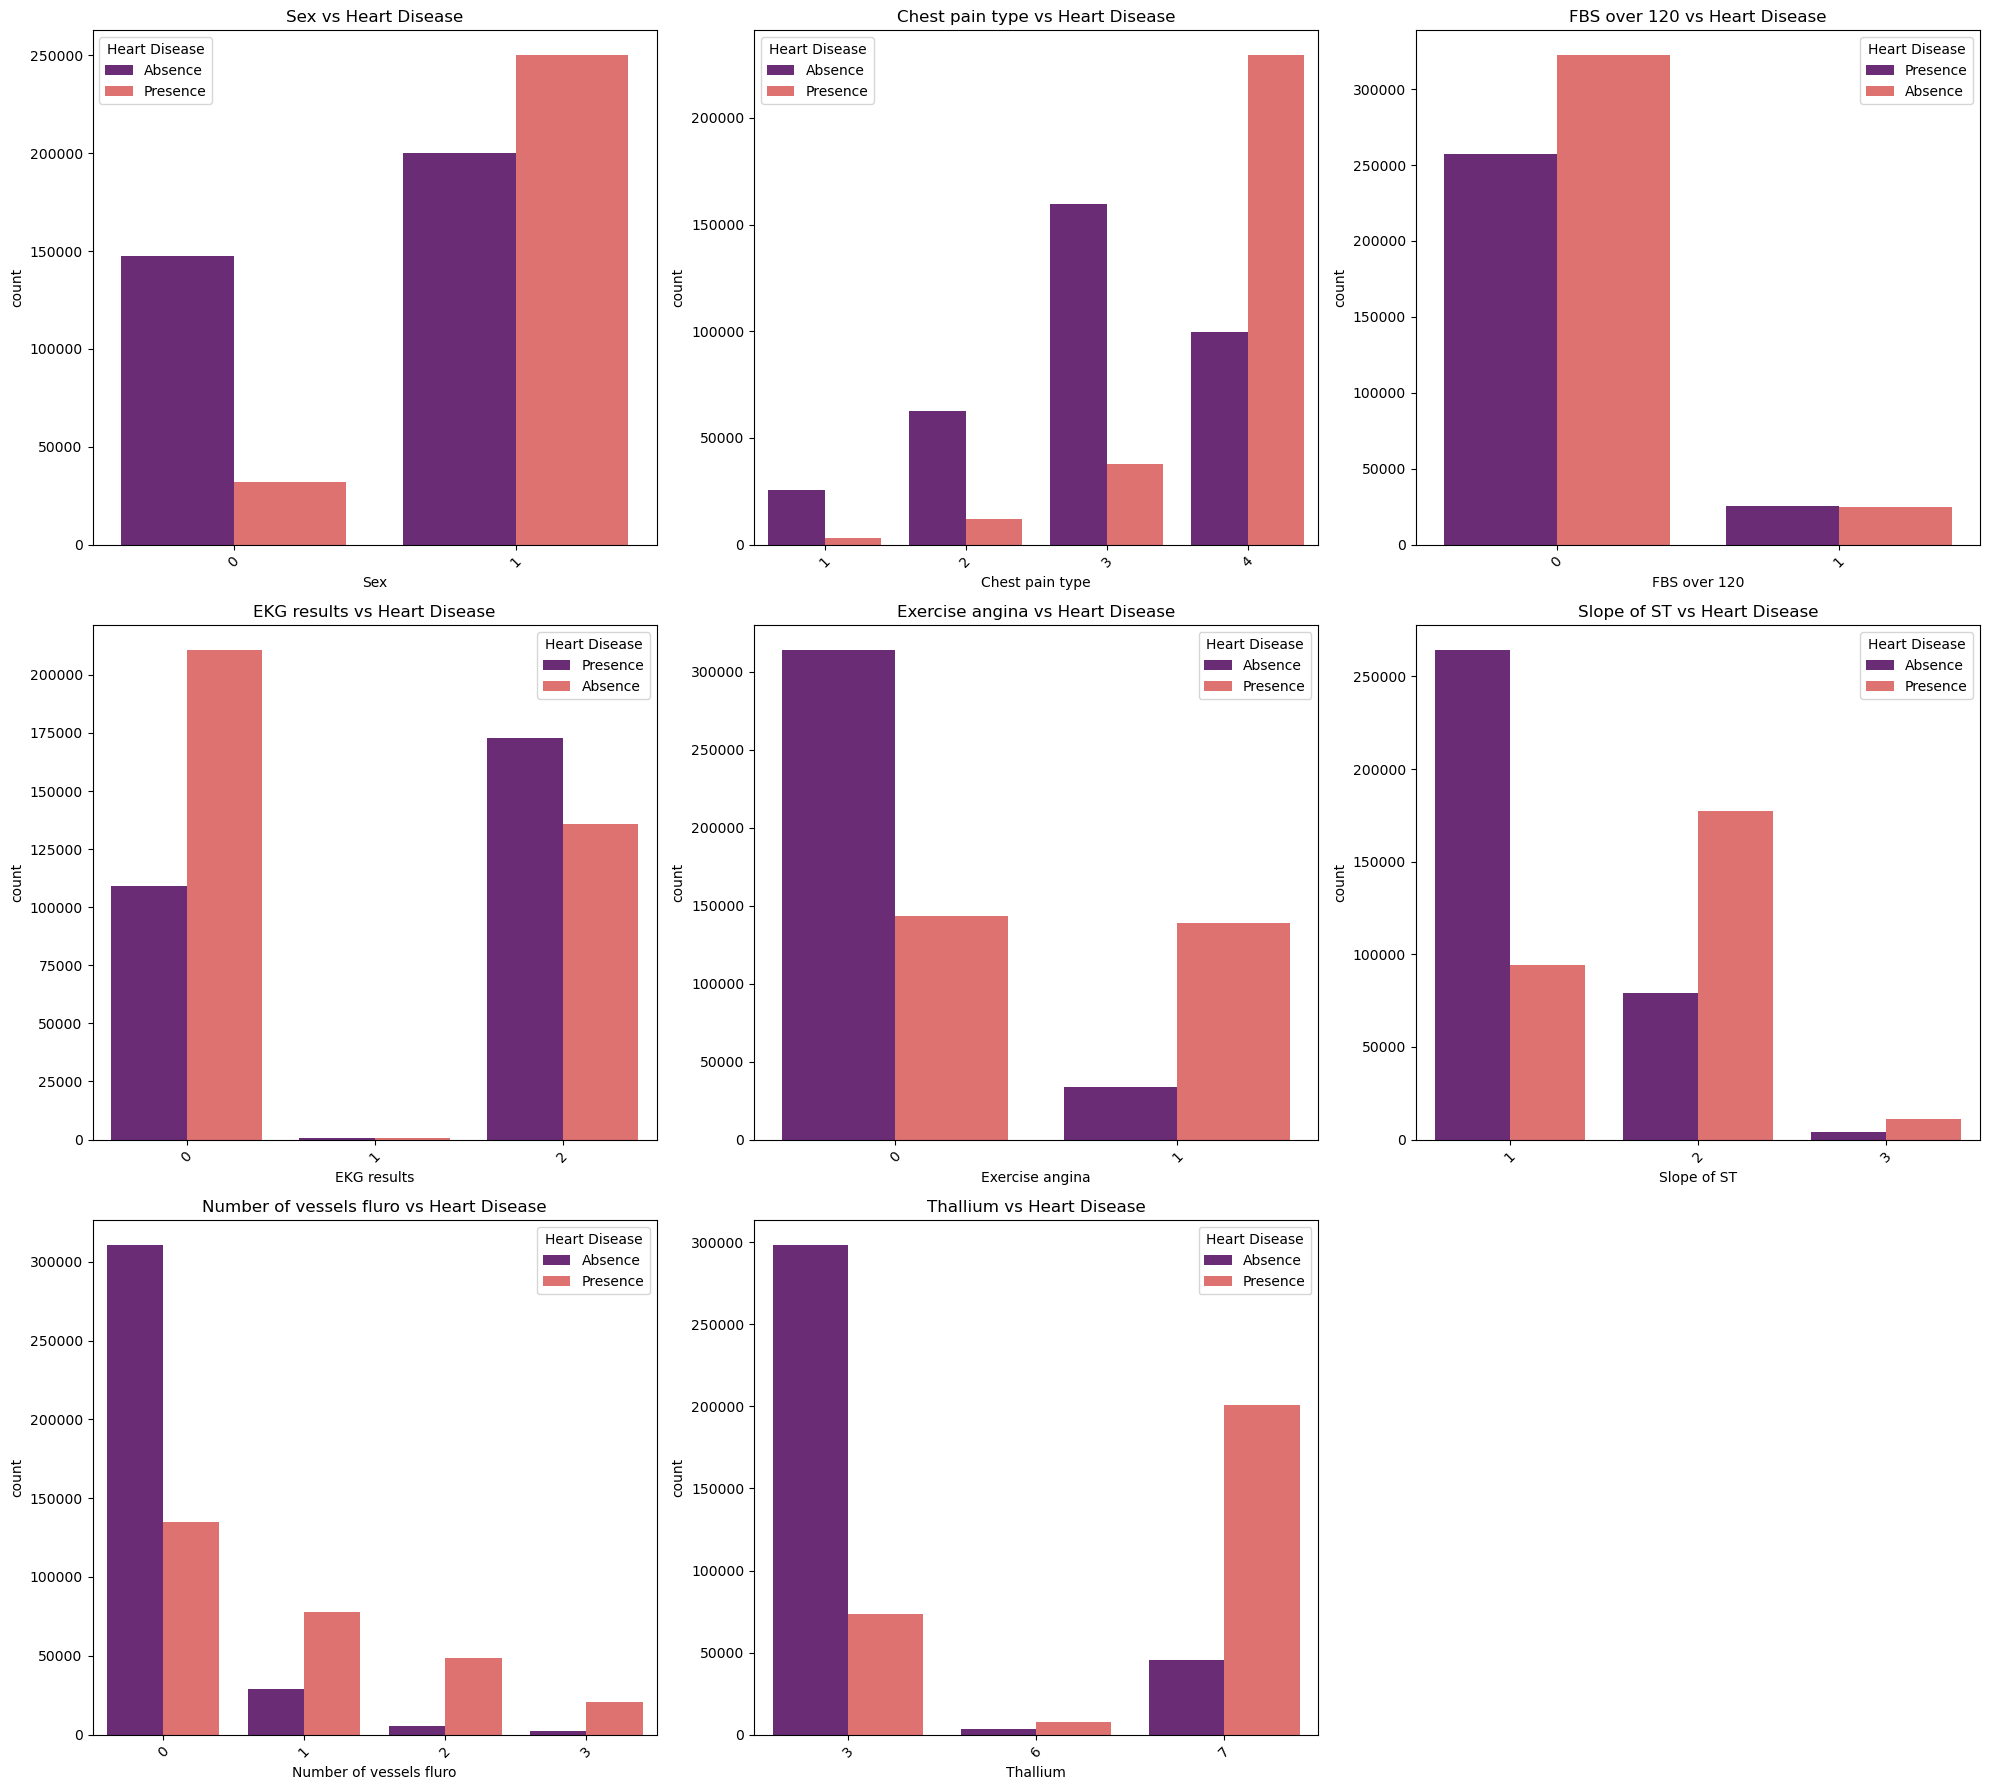

In [6]:
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=train, x=col, hue='Heart Disease', ax=axes[i], palette='magma')
    axes[i].set_title(f'{col} vs Heart Disease')
    axes[i].tick_params(axis='x', rotation=45)

fig.delaxes(axes[8])
plt.tight_layout()
plt.show()

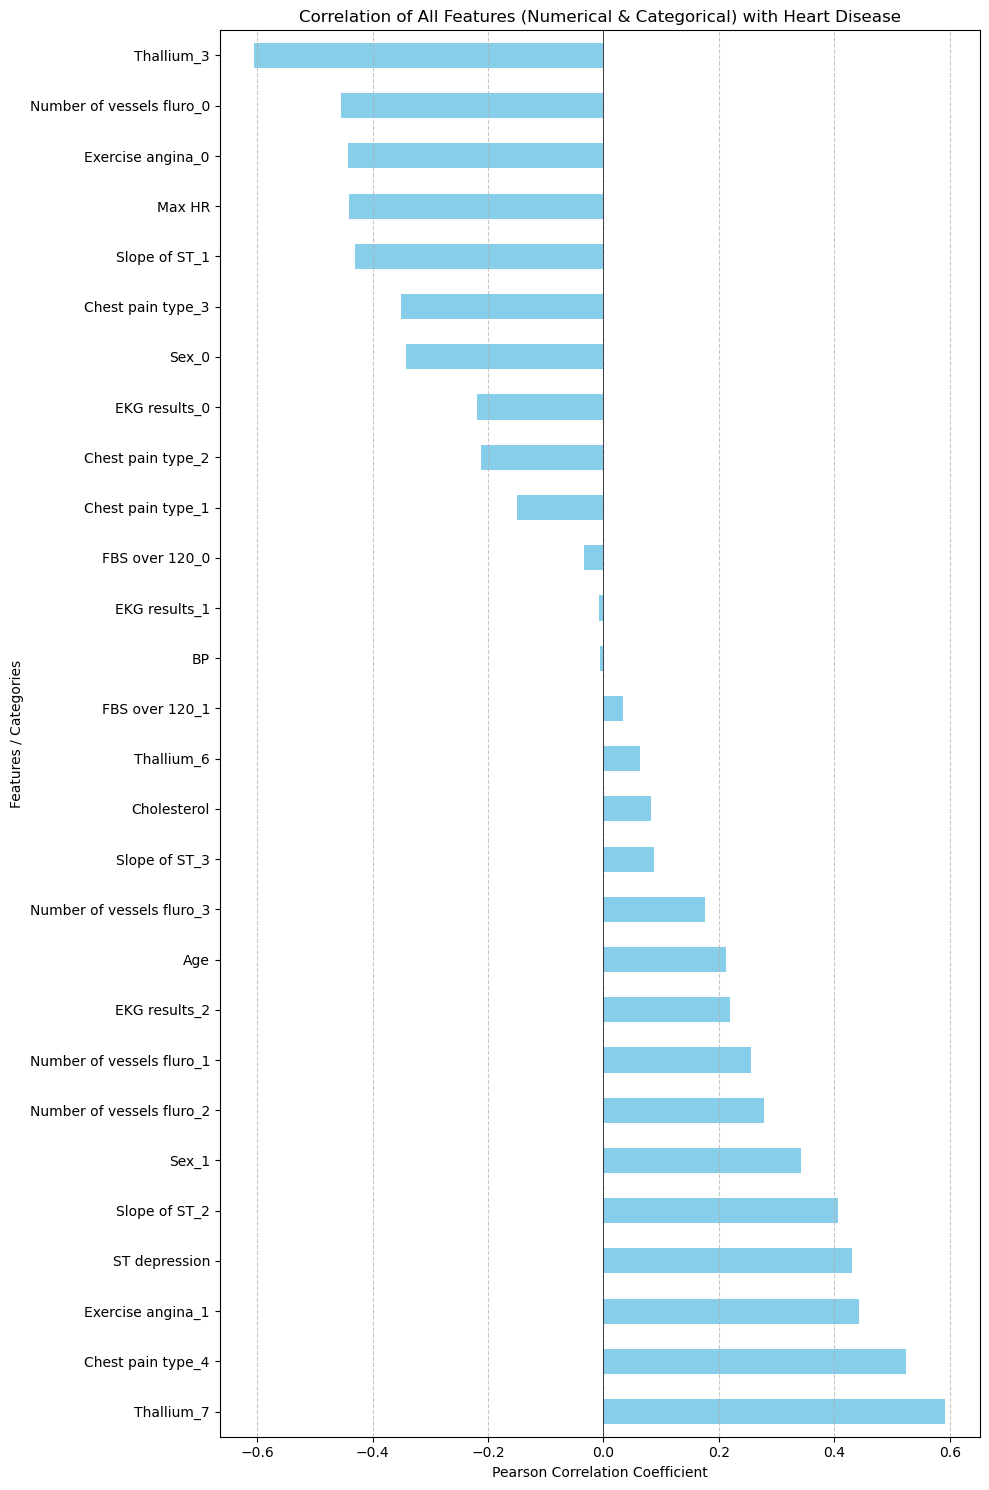

In [7]:


# 1. Prepare the data
temp_df = train.copy()

# Ensure target is numeric (1 for Presence, 0 for Absence)
target = 'Heart Disease'
if temp_df[target].dtype == 'object':
    temp_df[target] = temp_df[target].map({'Presence': 1, 'Absence': 0})

# 2. One-Hot Encode all categorical variables
# This creates a 0/1 column for every category (e.g., Sex_Male, Sex_Female)
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

df_encoded = pd.get_dummies(temp_df[num_cols + cat_cols + [target]], columns=cat_cols)

# 3. Calculate the correlation of everything with the Target
correlations = df_encoded.corr()[target].sort_values(ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 15))
# We drop the target itself so it doesn't show a 1.0 correlation with itself
correlations.drop(target).plot(kind='barh', color='skyblue')

plt.title('Correlation of All Features (Numerical & Categorical) with Heart Disease')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5) # Add a center line
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features / Categories')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
def create_medical_features(df):
    # Make a copy to avoid modifying the original data
    df = df.copy()
    
    # 1. Hypertension Flag (Medical threshold: BP > 140)
    df['is_hypertensive'] = (df['BP'] > 140).astype(int)
    
    # 2. High Cholesterol Flag (Medical threshold: Cholesterol > 240)
    df['is_high_cholesterol'] = (df['Cholesterol'] > 240).astype(int)
    
    # 3. Heart Rate Reserve (Theoretical max 220-Age minus actual Max HR)
    # A large gap suggests the heart cannot reach its potential under stress
    df['hr_reserve'] = (220 - df['Age']) - df['Max HR']
    
    # 4. Stress Index (ST depression relative to Max HR)
    # Higher ST depression with a lower Max HR is a strong danger sign
    df['stress_index'] = df['ST depression'] / (df['Max HR'] + 1)
    
    # 5. Age-Pressure Product (Age * BP)
    # Captures the compounding risk of high blood pressure over a long lifespan
    df['age_bp_product'] = df['Age'] * df['BP']
    
    # 6. ST-Slope Interaction
    # The 'Slope of ST' describes the shape of the EKG; multiplying it by 'ST depression'
    # amplifies the signal of the heart's electrical abnormality.
    df['st_slope_interaction'] = df['ST depression'] * df['Slope of ST']
    
    # 7. Total Risk Factor Count (Manual count of common 'Red Flags')
    # We add up boolean conditions to see how many risk factors are present at once
    df['total_risk_factors'] = (
        (df['Sex'] == 1).astype(int) + 
        (df['Exercise angina'] == 1).astype(int) + 
        (df['FBS over 120'] == 1).astype(int) + 
        df['is_hypertensive'] + 
        df['is_high_cholesterol']
    )
    
    # 8. Body Aging Index (Age * Cholesterol)
    df['age_chol_product'] = df['Age'] * df['Cholesterol']
    
    # 9. Vessel-Thallium Interaction
    # Two of the strongest predictors in heart datasets; combined they are very powerful.
    df['vessel_thall_interaction'] = df['Number of vessels fluro'] * df['Thallium']
    
    # 10. BP-Cholesterol Ratio
    # Helps differentiate between patients with high BP vs high Cholesterol
    df['bp_chol_ratio'] = df['BP'] / (df['Cholesterol'] + 1)
    
    return df

# Apply to your datasets
X = create_medical_features(X)
X_test = create_medical_features(X_test)

print("10 New features created successfully!")

10 New features created successfully!


In [49]:
# Updated list including your new features
num_cols = [
    'Age', 'BP', 'Cholesterol', 'Max HR', 
    'stress_index', 'st_slope_interaction', 
    'total_risk_factors', 'age_chol_product', 'vessel_thall_interaction'
]

# Keep your categorical columns the same
cat_cols = [
    'Sex', 'Chest pain type', 'EKG results', 
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium'
]

# Redefine your preprocessor with the new list
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
import numpy as np

def bin_st_by_unit(df):
    df = df.copy()
    # Floor rounding creates bins: [0,1), [1,2), [2,3), etc.
    df['st_bin_unit'] = np.floor(df['ST depression']).astype(int)
    
    # Optional: Cap the bins (e.g., everything above 4 is 'High')
    # This prevents the model from seeing a 'rare' bin in the test set
    df['st_bin_unit'] = df['st_bin_unit'].clip(upper=4)
    
    return df

# Apply to your data
#X = bin_st_by_unit(X)
#X_test = bin_st_by_unit(X_test)

# Numerical: Continuous values like Age or Blood Pressure
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# Categorical: Groups or classes like Sex or Thallium type
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
            'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

In [9]:
# Blueprint for numbers: Fill missing values with the middle (median) value, then scale them.
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Blueprint for categories: Fill missing values with the most common type, then assign a number code.
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine them into one 'Preprocessor'
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [ ]:
## Feb 17th
import pandas as pd
import numpy as np

# =========================
# Feature Engineering Function
# =========================

def create_heart_features(df):

    df = df.copy()

    # Interaction feature

    df['Chol_bin'] = pd.cut(df['Cholesterol'], bins=10, labels=False)


    df['Age_MaxHR'] = df['Age'] * df['Max HR']

    # Ratio features (safe division)
    df['ST_by_HR'] = df['ST depression'] / df['Max HR'].replace(0, np.nan)
    df['Chol_per_age'] = df['Cholesterol'] / df['Age'].replace(0, np.nan)
    df['BP_Chol'] = df['BP'] * df['Cholesterol'].replace(0, np.nan)

    df['HR_per_age'] = df['Max HR'] / df['Age'].replace(0, np.nan)

    df['ST_Age'] = df['ST depression'] * df['Age'].replace(0, np.nan)

    # Fill possible NaN from division
    df['ST_by_HR'] = df['ST_by_HR'].fillna(0)
    df['Chol_per_age'] = df['Chol_per_age'].fillna(0)

    # Binning features
    df['Age_bin'] = pd.cut(
        df['Age'],
        bins=10,
        labels=False
    )

    df['HR_bin'] = pd.cut(
        df['Max HR'],
        bins=10,
        labels=False
    )
    df['Chol_log'] = np.log1p(df['Cholesterol'])
    df['BP_log'] = np.log1p(df['BP'])
    return df


# =========================
# Apply to dataset
# =========================

X = create_heart_features(X)
X_test = create_heart_features(X_test)

bins = np.arange(0, 6.2 + 0.5, 0.5)
X['ST_dep_bin'] = pd.cut(
    X['ST depression'],
    bins=bins,
    labels=False,
    include_lowest=True
)


In [ ]:
###Feb 17th
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
num_cols = [

    # original numeric
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',
    'BP_Chol',
    'HR_per_age',
    'ST_Age',

    # NEW engineered numeric features
    'Age_MaxHR',
    'ST_by_HR',
    'Chol_per_age',
    'Chol_log',

]

cat_cols = [

    # original categorical
    'Chest pain type',
    'EKG results',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium',

    # NEW engineered categorical features
    'Age_bin',
    'HR_bin',
    'Chol_bin',
]

binary_cols = [

    'Sex',
    'FBS over 120',
    'Exercise angina'

]


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

In [12]:
# 5-Fold Cross-Validation: Split the data into 5 parts. 
# Train on 4 parts, test on 1 part. Repeat 5 times.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [13]:
# Initialize storage for our results
oof_preds = np.zeros(len(X))             # Out-of-fold predictions (for validation)
test_preds = np.zeros(len(X_test))       # Predictions for the competition test set
fold_scores = []                         # To keep track of ROC-AUC for each fold

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")
# Initialize list to store importance from each fold
all_importances = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # 1. Split the data based on the current fold
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # 2. Assemble the full model (Cleaning + Learning)
    # We put the 'preprocessor' and 'CatBoostClassifier' into one Pipeline
    model_pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=4,
            verbose=False,
            allow_writing_files=False
        ))
    ])
    
    # 3. Fit the model
    # The preprocessor ONLY learns from the training fold here (No Leakage!)
    model_pipeline.fit(X_train_fold, y_train_fold)
    # NEW: Get feature names and importance
    # We get names from the preprocessor step of the pipeline
    feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()
    # We get importance from the classifier step
    importances = model_pipeline.named_steps['clf'].get_feature_importance()
    
    all_importances.append(importances)

    # 4. Validate the model
    # Predict probabilities for the 20% of data the model hasn't seen yet
    val_probs = model_pipeline.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # 5. Score the fold
    score = roc_auc_score(y_val_fold, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold+1} ROC-AUC: {score:.4f}")

    # 6. Predict on Test Data
    # We add this fold's predictions to our total (we will average them at the end)
    test_preds += model_pipeline.predict_proba(X_test)[:, 1] / skf.get_n_splits()
    

print('-' * 30)
print(f"Final Mean ROC-AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

# February 17th 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
# reshape to 2D
meta_X = oof_preds.reshape(-1, 1)
meta_X_test = test_preds.reshape(-1, 1)

# train meta model
meta_model = LogisticRegression()

meta_model.fit(meta_X, y)

# evaluate meta model performance
meta_oof_preds = meta_model.predict_proba(meta_X)[:, 1]

meta_score = roc_auc_score(y, meta_oof_preds)

print(f"Meta Model ROC-AUC: {meta_score:.4f}")

# final test predictions
final_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]



Starting 5-fold Cross-Validation...
Fold 1 ROC-AUC: 0.9556
Fold 2 ROC-AUC: 0.9546
Fold 3 ROC-AUC: 0.9554
Fold 4 ROC-AUC: 0.9549
Fold 5 ROC-AUC: 0.9558
------------------------------
Final Mean ROC-AUC: 0.9553 (+/- 0.0005)
Meta Model ROC-AUC: 0.9553


In [62]:
# Feb 17th
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier


# ===============================
# STORAGE
# ===============================

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")

all_importances = []


# ===============================
# STRONG MODEL TRAINING
# ===============================

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):

    X_train_fold = X.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]


    model_pipeline = Pipeline([

        ('prep', preprocessor),

        ('clf', CatBoostClassifier(

            iterations=1000,
            learning_rate=0.05,
            depth=6,

            verbose=False,
            allow_writing_files=False

        ))

    ])


    model_pipeline.fit(X_train_fold, y_train_fold)


    importances = model_pipeline.named_steps['clf'].get_feature_importance()

    all_importances.append(importances)



    val_probs = model_pipeline.predict_proba(X_val_fold)[:,1]

    oof_preds[val_idx] = val_probs



    score = roc_auc_score(y_val_fold, val_probs)

    fold_scores.append(score)

    print(f"Fold {fold+1} ROC-AUC: {score:.5f}")



    test_preds += model_pipeline.predict_proba(X_test)[:,1] / skf.get_n_splits()



print('-'*40)

print(f"Strong Model Mean ROC-AUC: {np.mean(fold_scores):.5f}")


# ============================================================
# HARD SAMPLE DETECTION
# ============================================================

hard_idx = (

    ((oof_preds > 0.4) & (oof_preds < 0.6))

    |

    ((oof_preds > 0.5) != y.values)

)


X_hard = X.iloc[hard_idx]

y_hard = y.iloc[hard_idx]


print(f"Hard samples count: {len(X_hard)}")



# ============================================================
# WEAK MODEL TRAINING
# ============================================================


weak_pipeline = Pipeline([

    ('prep', preprocessor),

    ('clf', CatBoostClassifier(

        iterations=500,
        learning_rate=0.1,
        depth=3,

        verbose=False,
        allow_writing_files=False

    ))

])


weak_pipeline.fit(X_hard, y_hard)



# ============================================================
# WEAK MODEL PREDICTIONS
# ============================================================


weak_oof_preds = weak_pipeline.predict_proba(X)[:,1]

weak_test_preds = weak_pipeline.predict_proba(X_test)[:,1]



# ============================================================
# FINAL ENSEMBLE
# ============================================================

STRONG_WEIGHT = 0.9
WEAK_WEIGHT   = 0.1


final_oof_preds = (

    STRONG_WEIGHT * oof_preds

    +

    WEAK_WEIGHT * weak_oof_preds

)


final_test_preds = (

    STRONG_WEIGHT * test_preds

    +

    WEAK_WEIGHT * weak_test_preds

)



# ============================================================
# FINAL SCORE
# ============================================================

final_score = roc_auc_score(y, final_oof_preds)


print('-'*40)

print(f"Final Ensemble ROC-AUC: {final_score:.5f}")




# =========================
# META MODEL (STACKING)
# =========================

meta_X = final_oof_preds.reshape(-1, 1)
meta_X_test = final_test_preds.reshape(-1, 1)


meta_model = LogisticRegression()


meta_model.fit(meta_X, y)



meta_oof_preds = meta_model.predict_proba(meta_X)[:, 1]


meta_score = roc_auc_score(y, meta_oof_preds)


print(f"Meta Model ROC-AUC: {meta_score:.5f}")



# =========================
# FINAL TEST PREDICTIONS
# =========================

final_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]



Starting 5-fold Cross-Validation...
Fold 1 ROC-AUC: 0.95570
Fold 2 ROC-AUC: 0.95464
Fold 3 ROC-AUC: 0.95546
Fold 4 ROC-AUC: 0.95502
Fold 5 ROC-AUC: 0.95589
----------------------------------------
Strong Model Mean ROC-AUC: 0.95534
Hard samples count: 91089
----------------------------------------
Final Ensemble ROC-AUC: 0.95536
Meta Model ROC-AUC: 0.95536


In [48]:
###### FEB 17th
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression


# =========================
# DEFINE categorical columns
# =========================

cat_features = [

    'Chest pain type',
    'EKG results',
    'Slope of ST',
    'Number of vessels fluro',
    'Thallium',

    'Age_bin',
    'HR_bin'

]


# OPTIONAL but recommended: convert to string
for col in cat_features:

    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)



# =========================
# Storage
# =========================

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

fold_scores = []

all_importances = []


print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")


# =========================
# CROSS VALIDATION
# =========================

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):


    X_train_fold = X.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]



    # =========================
    # MODEL
    # =========================

    model = CatBoostClassifier(

        iterations=2500,
        learning_rate=0.02,
        depth=6,

        eval_metric='AUC',

        random_strength=0.5,
        bagging_temperature=0.2,

        early_stopping_rounds=200,

        verbose=False

    )



    # =========================
    # TRAIN
    # =========================

    model.fit(

        X_train_fold,
        y_train_fold,

        cat_features=cat_features,

        eval_set=(X_val_fold, y_val_fold)

    )



    # =========================
    # FEATURE IMPORTANCE
    # =========================

    importances = model.get_feature_importance()

    all_importances.append(importances)



    # =========================
    # VALIDATION PREDICTION
    # =========================

    val_probs = model.predict_proba(X_val_fold)[:, 1]

    oof_preds[val_idx] = val_probs



    score = roc_auc_score(y_val_fold, val_probs)

    fold_scores.append(score)

    print(f"Fold {fold+1} ROC-AUC: {score:.5f}")



    # =========================
    # TEST PREDICTION
    # =========================

    test_preds += model.predict_proba(X_test)[:, 1] / skf.get_n_splits()



# =========================
# FINAL CV SCORE
# =========================

print('-'*40)

print(f"Final Mean ROC-AUC: {np.mean(fold_scores):.5f}")



# =========================
# META MODEL (STACKING)
# =========================

meta_X = oof_preds.reshape(-1, 1)
meta_X_test = test_preds.reshape(-1, 1)


meta_model = LogisticRegression()


meta_model.fit(meta_X, y)



meta_oof_preds = meta_model.predict_proba(meta_X)[:, 1]


meta_score = roc_auc_score(y, meta_oof_preds)


print(f"Meta Model ROC-AUC: {meta_score:.5f}")



# =========================
# FINAL TEST PREDICTIONS
# =========================

final_test_preds = meta_model.predict_proba(meta_X_test)[:, 1]


Starting 5-fold Cross-Validation...
Fold 1 ROC-AUC: 0.95568
Fold 2 ROC-AUC: 0.95466
Fold 3 ROC-AUC: 0.95548
Fold 4 ROC-AUC: 0.95507
Fold 5 ROC-AUC: 0.95586
----------------------------------------
Final Mean ROC-AUC: 0.95535
Meta Model ROC-AUC: 0.95535


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Initialize storage
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

# NEW: store misclassified samples
misclassified_rows = []

# Feature importance storage
all_importances = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    model_pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            verbose=False,
            allow_writing_files=False
        ))
    ])
    
    model_pipeline.fit(X_train_fold, y_train_fold)

    # Feature importance
    feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()
    importances = model_pipeline.named_steps['clf'].get_feature_importance()
    all_importances.append(importances)

    # Validation predictions
    val_probs = model_pipeline.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Convert probs to class (0/1)
    val_preds = (val_probs >= 0.5).astype(int)

    # Find misclassified samples
    mis_mask = val_preds != y_val_fold.values
    X_mis = X_val_fold[mis_mask]
    y_mis = y_val_fold[mis_mask]

    # Store them
    mis_df = X_mis.copy()
    mis_df["target"] = y_mis.values
    mis_df["probability"]=val_probs[mis_mask]
    misclassified_rows.append(mis_df)

    # Fold score
    score = roc_auc_score(y_val_fold, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold+1} ROC-AUC: {score:.4f}")

    # Test predictions
    test_preds += model_pipeline.predict_proba(X_test)[:, 1] / skf.get_n_splits()

print('-' * 30)
print(f"Final Mean ROC-AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

# ============================
# ANALYZE MISCLASSIFIED ROWS
# ============================

misclassified_df = pd.concat(misclassified_rows)

# Correlation with target
corr_with_target = misclassified_df.corr(numeric_only=True)["target"].sort_values()

# Plot
plt.figure(figsize=(8, 12))
corr_with_target.drop("target").plot(kind="barh")
plt.title("Correlation of Misclassified Samples with Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

Starting 5-fold Cross-Validation...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2214
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


AttributeError: 'LGBMClassifier' object has no attribute 'get_feature_importance'

In [24]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# ============================
# THRESHOLD OPTIMIZATION
# ============================

thresholds = np.linspace(0.3, 0.7, 100)

f1_scores = []
acc_scores = []

for t in thresholds:
    preds = (oof_preds >= t).astype(int)
    f1_scores.append(f1_score(y, preds))
    acc_scores.append(accuracy_score(y, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1 score: {f1_scores[best_idx]:.4f}")
print(f"Accuracy at best threshold: {acc_scores[best_idx]:.4f}")

Best threshold: 0.433
Best F1 score: 0.8764
Accuracy at best threshold: 0.8876


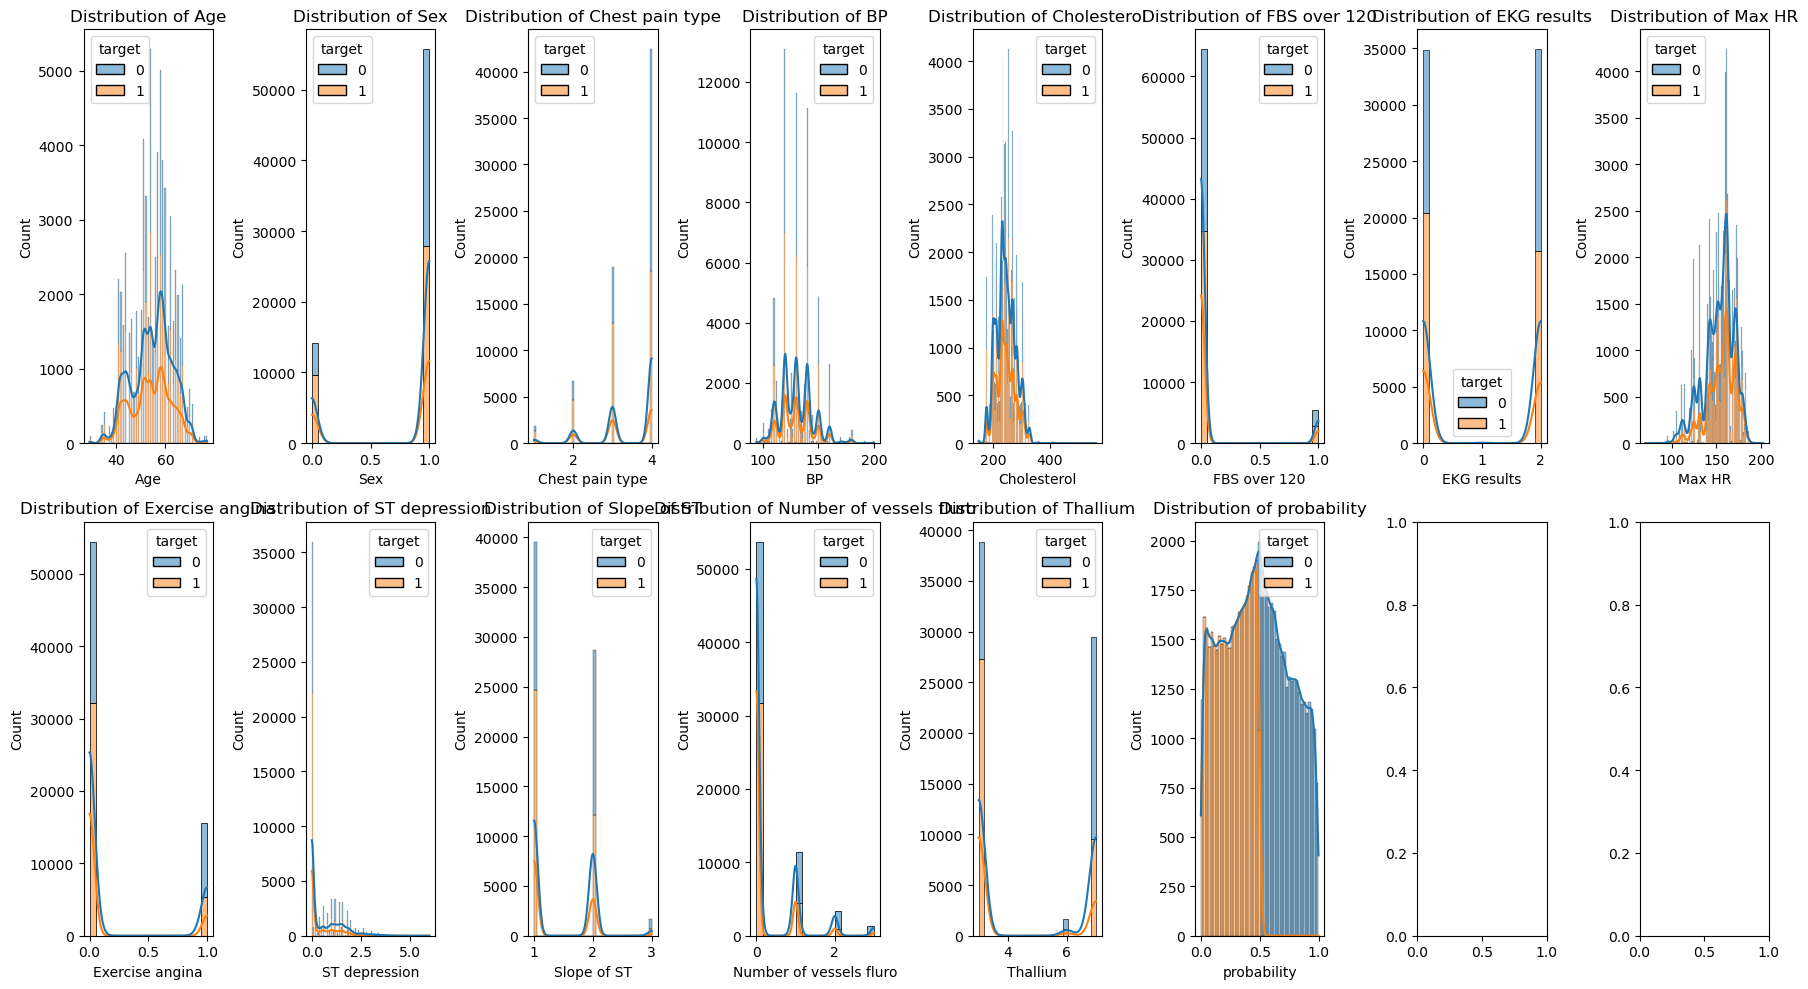

In [22]:

#num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
num_cols = ['Age',	'Sex',	'Chest pain type',	'BP',	'Cholesterol',	'FBS over 120',	'EKG results','Max HR',	'Exercise angina',	'ST depression',	'Slope of ST',	'Number of vessels fluro',	'Thallium','probability']

fig, axes = plt.subplots(2,8, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=misclassified_df, x=col, hue='target', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(f'Distribution of {col}')

#fig.delaxes(axes[5]) # Remove the extra empty plot
plt.tight_layout()
plt.show()


(array([6939., 6940., 7116., 7772., 9563., 8337., 7240., 6204., 5773.,
        4911.]),
 array([4.83601669e-04, 1.00356328e-01, 2.00229054e-01, 3.00101780e-01,
        3.99974506e-01, 4.99847232e-01, 5.99719958e-01, 6.99592684e-01,
        7.99465410e-01, 8.99338136e-01, 9.99210862e-01]),
 <BarContainer object of 10 artists>)

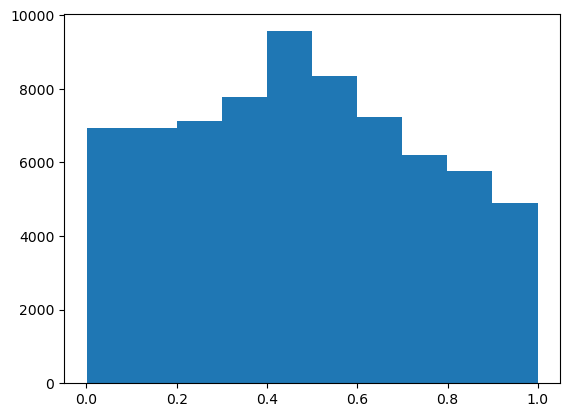

In [45]:
plt.hist(misclassified_df['probability'])


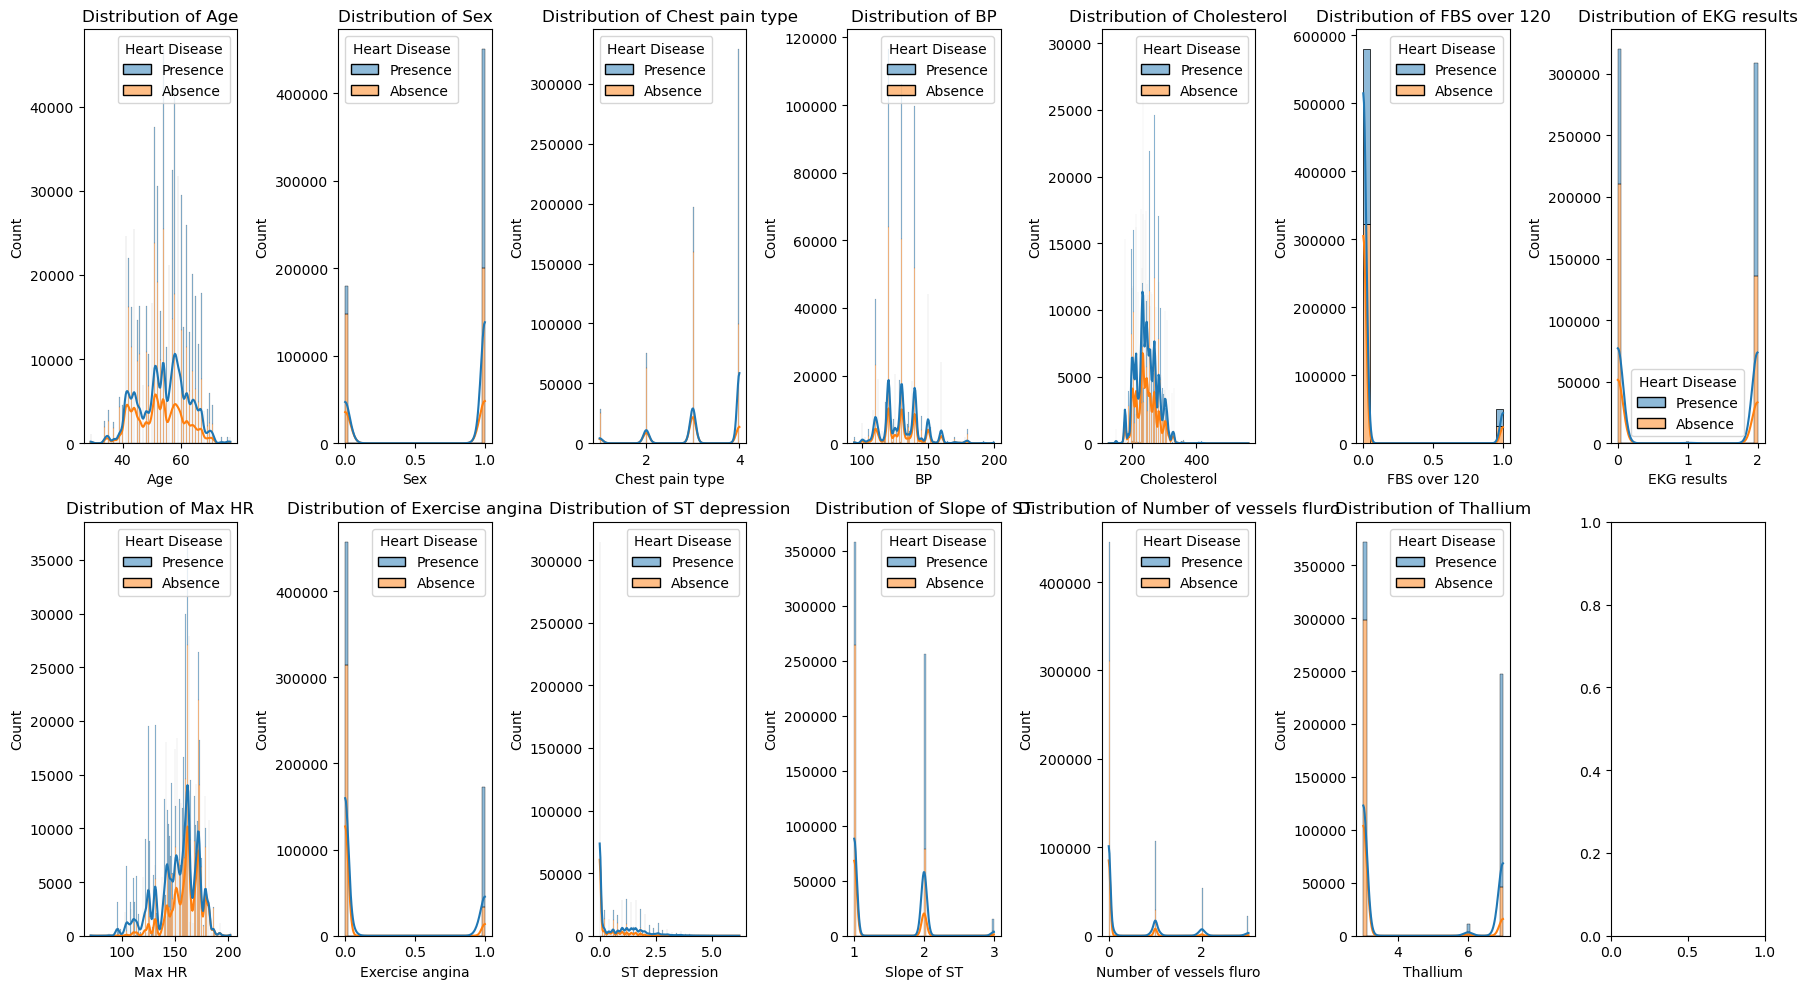

In [28]:
#num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
num_cols = ['Age',	'Sex',	'Chest pain type',	'BP',	'Cholesterol',	'FBS over 120',	'EKG results','Max HR',	'Exercise angina',	'ST depression',	'Slope of ST',	'Number of vessels fluro',	'Thallium']

fig, axes = plt.subplots(2,7, figsize=(18, 10))

#fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train, x=col, hue='Heart Disease', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(f'Distribution of {col}')

#fig.delaxes(axes[5]) # Remove the extra empty plot
plt.tight_layout()
plt.show()


In [34]:
# True labels and predicted probabilities from CV
y_true = y.values
y_pred = (oof_preds >= 0.5).astype(int)  # adjust threshold if needed

# Build analysis dataframe
analysis_df = X.copy()
analysis_df["target"] = y_true
analysis_df["pred"] = y_pred
analysis_df["correct"] = (analysis_df["target"] == analysis_df["pred"]).astype(int)

correct_df = analysis_df[analysis_df["correct"] == 1]
misclassified_df = analysis_df[analysis_df["correct"] == 0]

print("Correct:", correct_df.shape)
print("Misclassified:", misclassified_df.shape)

Correct: (560044, 16)
Misclassified: (69956, 16)


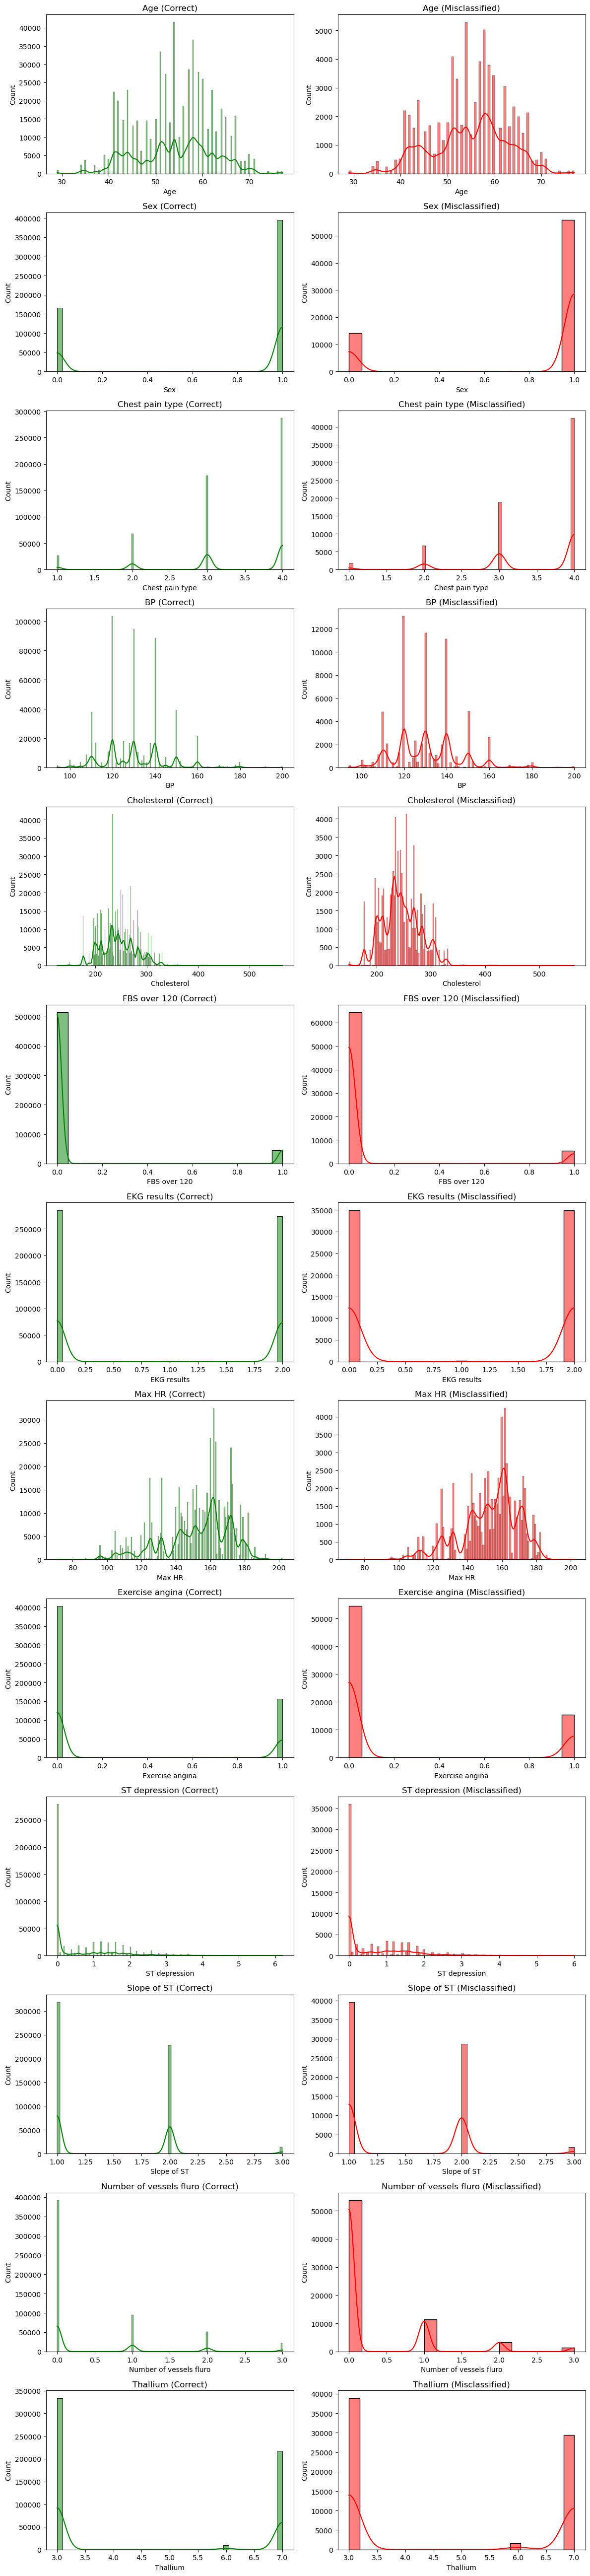

In [36]:
num_cols = ['Age',	'Sex',	'Chest pain type',	'BP',	'Cholesterol',	'FBS over 120',	'EKG results','Max HR',	'Exercise angina',	'ST depression',	'Slope of ST',	'Number of vessels fluro',	'Thallium']

#fig, axes = plt.subplots(2,7, figsize=(18, 10))

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(correct_df[col], kde=True, ax=axes[i,0], color="green")
    axes[i,0].set_title(f"{col} (Correct)")

    sns.histplot(misclassified_df[col], kde=True, ax=axes[i,1], color="red")
    axes[i,1].set_title(f"{col} (Misclassified)")

plt.tight_layout()
plt.show()

In [37]:
diff_stats = []

for col in num_cols:
    diff_stats.append({
        "feature": col,
        "correct_mean": correct_df[col].mean(),
        "mis_mean": misclassified_df[col].mean(),
        "mean_diff": correct_df[col].mean() - misclassified_df[col].mean()
    })

pd.DataFrame(diff_stats).sort_values("mean_diff", key=abs, ascending=False)

,feature,correct_mean,mis_mean,mean_diff
0,Age,54.062791,54.728444,-0.665652
7,Max HR,152.787829,153.048402,-0.260573
2,Chest pain type,3.294564,3.458360,-0.163795
12,Thallium,4.602056,4.753502,-0.151446
11,Number of vessels fluro,0.467431,0.319815,0.147616
3,BP,130.510687,130.391332,0.119355
9,ST depression,0.727659,0.622910,0.104749
1,Sex,0.704507,0.796615,-0.092108
4,Cholesterol,245.003568,245.077835,-0.074267
8,Exercise angina,0.280235,0.221611,0.058624


In [38]:
from scipy import stats
import numpy as np

def quantify_differences(correct_df, mis_df, columns):
    results = []
    
    for col in columns:
        # 1. Determine if the column is categorical or continuous
        # (Assuming categorical if it has few unique values)
        is_categorical = correct_df[col].nunique() <= 5 
        
        if not is_categorical:
            # Metric for Continuous: Cohen's d (Effect Size)
            m1, m2 = correct_df[col].mean(), mis_df[col].mean()
            s1, s2 = correct_df[col].std(), mis_df[col].std()
            n1, n2 = len(correct_df), len(mis_df)
            
            # Pooled standard deviation
            pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
            effect_size = (m1 - m2) / pooled_std if pooled_std != 0 else 0
            
            results.append({
                "Feature": col,
                "Type": "Continuous",
                "Metric": "Cohen's d",
                "Value": round(effect_size, 4),
                "Note": "Large (>0.8) means major shift in distribution"
            })
        else:
            # Metric for Categorical: Distribution Shift (Kullback-Leibler Divergence or simple % Diff)
            # We'll calculate the 'Maximum Percentage Difference' in categories
            c_dist = correct_df[col].value_counts(normalize=True)
            m_dist = mis_df[col].value_counts(normalize=True)
            
            # Find the category with the biggest gap in representation
            max_diff = (c_dist - m_dist).abs().max()
            
            results.append({
                "Feature": col,
                "Type": "Categorical",
                "Metric": "Max % Shift",
                "Value": round(max_diff, 4),
                "Note": "High value means specific category is being misclassified"
            })

    return pd.DataFrame(results).sort_values("Value", key=abs, ascending=False)

# Run it
num_cols = ['Age',	'Sex',	'Chest pain type',	'BP',	'Cholesterol',	'FBS over 120',	'EKG results','Max HR',	'Exercise angina',	'ST depression',	'Slope of ST',	'Number of vessels fluro',	'Thallium']

comparison_df = quantify_differences(correct_df, misclassified_df, num_cols)
display(comparison_df)

,Feature,Type,Metric,Value,Note
9,ST depression,Continuous,Cohen's d,0.1105,Large (>0.8) means major shift in distribution
2,Chest pain type,Categorical,Max % Shift,0.0944,High value means specific category is being mi...
1,Sex,Categorical,Max % Shift,0.0921,High value means specific category is being mi...
0,Age,Continuous,Cohen's d,-0.0806,Large (>0.8) means major shift in distribution
11,Number of vessels fluro,Categorical,Max % Shift,0.0678,High value means specific category is being mi...
8,Exercise angina,Categorical,Max % Shift,0.0586,High value means specific category is being mi...
12,Thallium,Categorical,Max % Shift,0.0396,High value means specific category is being mi...
7,Max HR,Continuous,Cohen's d,-0.0136,Large (>0.8) means major shift in distribution
6,EKG results,Categorical,Max % Shift,0.0107,High value means specific category is being mi...
3,BP,Continuous,Cohen's d,0.0080,Large (>0.8) means major shift in distribution


In [40]:
misclassified_df['Sex'].astype(str) + "_" + misclassified_df['Chest pain type'].astype(str)

27        1_4
44        1_2
70        0_3
72        1_3
73        1_3
         ... 
629990    1_4
629992    1_1
629994    1_4
629996    1_4
629998    1_4
Length: 69956, dtype: object

C:\Users\Mohamad\AppData\Local\Temp\ipykernel_13708\1688852612.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')


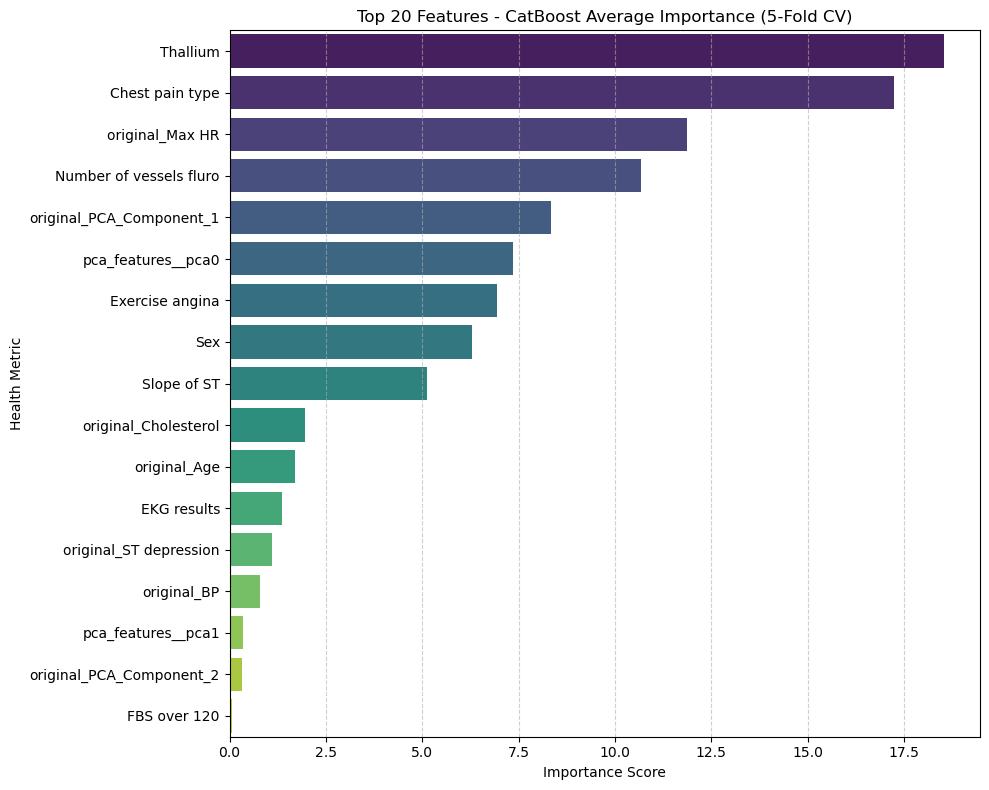

In [72]:
# 1. Calculate the average importance across all folds
mean_importance = np.mean(all_importances, axis=0)

# 2. Create a DataFrame for easy plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_importance
}).sort_values(by='Importance', ascending=False)

# 3. Clean up the feature names (remove the 'num__' and 'cat__' prefixes)
importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')

# 4. Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='viridis')

plt.title('Top 20 Features - CatBoost Average Importance (5-Fold CV)')
plt.xlabel('Importance Score')
plt.ylabel('Health Metric')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
# Create a DataFrame in the format required by the competition
submission = pd.DataFrame({
    'id': test_df['id'],            # Keep the original IDs
    'Heart Disease': final_test_preds     # Use our averaged probability predictions
})

# Save to a CSV file
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' has been created successfully!")
# Display the first few rows to double check
print(submission.head())

Submission file 'submission.csv' has been created successfully!
       id  Heart Disease
0  630000       0.944505
1  630001       0.038913
2  630002       0.960295
3  630003       0.038193
4  630004       0.113254


In [77]:
import optuna
from sklearn.model_selection import cross_val_score

# Ensure your patch from Step 1 is still active if you restarted the kernel!

c:\Users\Mohamad\anaconda3\envs\kaggle-competition-heartDisease\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [78]:
def objective(trial):
    # 1. Suggest hyperparameters
    param = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100),
        "random_strength": trial.suggest_float("random_strength", 1e-8, 10.0, log=True),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"]),
        "od_type": "Iter",
        "od_wait": 50,
        "verbose": False,
        "allow_writing_files": False
    }

    # Conditional parameter for bootstrap types
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    # 2. Build the pipeline with the suggested params
    model = Pipeline([
        ('prep', preprocessor), # Use your established preprocessor
        ('clf', CatBoostClassifier(**param))
    ])

    # 3. Perform a quick Cross-Validation (3 folds for speed)
    # Use 'roc_auc' as the evaluation metric
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return score.mean()

In [83]:
# 1. Capture the best parameters found by Optuna
# study.best_params is a dictionary created after running study.optimize()
best_params = study.best_params.copy()

# 2. Add the required static parameters
best_params.update({
    "iterations": 1000,
    "verbose": False,
    "allow_writing_files": False,
    "od_type": "Iter",
    "od_wait": 50,
    "eval_metric": "AUC"
})

# 3. Storage for results
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
all_importances = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation with Optuna parameters...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Split the data
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # Assemble the model using the optimized parameters
    # The ** operator "unpacks" the dictionary into keyword arguments
    model_pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(**best_params))
    ])
    
    # Fit the model
    model_pipeline.fit(X_train_fold, y_train_fold)
    
    # Feature Importance Tracking
    feature_names = model_pipeline.named_steps['prep'].get_feature_names_out()
    importances = model_pipeline.named_steps['clf'].get_feature_importance()
    all_importances.append(importances)

    # Validation Predictions
    val_probs = model_pipeline.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = val_probs
    
    # Scoring
    score = roc_auc_score(y_val_fold, val_probs)
    fold_scores.append(score)
    print(f"Fold {fold+1} ROC-AUC: {score:.4f}")

    # Test Set Predictions (Ensembling)
    test_preds += model_pipeline.predict_proba(X_test)[:, 1] / skf.get_n_splits()

print('-' * 30)
print(f"Optimized Mean ROC-AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

Starting 5-fold Cross-Validation with Optuna parameters...
Fold 1 ROC-AUC: 0.9558
Fold 2 ROC-AUC: 0.9547
Fold 3 ROC-AUC: 0.9555
Fold 4 ROC-AUC: 0.9551
Fold 5 ROC-AUC: 0.9559
------------------------------
Optimized Mean ROC-AUC: 0.9554 (+/- 0.0004)


In [81]:
import optuna

# 1. Define the search space
def objective(trial):
    param = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli"]),
        "iterations": 500, # Lower for speed during tuning
        "verbose": False,
        "allow_writing_files": False
    }
    
    # Simple pipeline for the study
    model = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(**param))
    ])
    
    # Get a quick CV score
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    return score.mean()

# 2. RUN THE STUDY (This creates the 'study' variable)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # 10 trials for a quick test, use 30+ for best results

print("Optimization done! You can now run the training loop.")

[I 2026-02-14 21:26:20,205] A new study created in memory with name: no-name-5e220db5-1a12-4404-b0c0-b193c6dfcb33
[I 2026-02-14 21:26:38,997] Trial 0 finished with value: 0.9515571981631655 and parameters: {'learning_rate': 0.003932464132851474, 'depth': 5, 'l2_leaf_reg': 1.7536104308189615, 'bootstrap_type': 'Bayesian'}. Best is trial 0 with value: 0.9515571981631655.
[I 2026-02-14 21:26:54,690] Trial 1 finished with value: 0.9551731947088018 and parameters: {'learning_rate': 0.08894271352306866, 'depth': 4, 'l2_leaf_reg': 7.997425554590063, 'bootstrap_type': 'Bernoulli'}. Best is trial 1 with value: 0.9551731947088018.
[I 2026-02-14 21:27:19,441] Trial 2 finished with value: 0.9522428888362514 and parameters: {'learning_rate': 0.0028833240931202242, 'depth': 8, 'l2_leaf_reg': 4.045446159685564, 'bootstrap_type': 'Bayesian'}. Best is trial 1 with value: 0.9551731947088018.
[I 2026-02-14 21:27:39,472] Trial 3 finished with value: 0.9501620654295815 and parameters: {'learning_rate': 0.0

Optimization done! You can now run the training loop.


In [44]:
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch

# Convert to numpy (TabNet needs numpy)
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

clf = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax"
)

clf.fit(
    X_train_np, y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# Predictions
y_pred = clf.predict(X_test_np)
y_prob = clf.predict_proba(X_test_np)[:,1]

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print("F1:", f1_score(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))


OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\Mohamad\anaconda3\envs\kaggle-competition-heartDisease\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

Best F1 threshold: 0.431
Best Accuracy threshold: 0.496


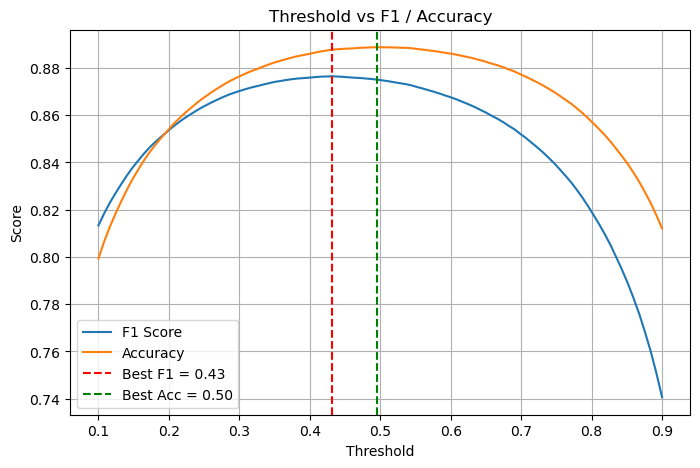

In [32]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.linspace(0.1, 0.9, 100)

f1_scores = []
acc_scores = []

for t in thresholds:
    preds = (oof_preds >= t).astype(int)
    f1_scores.append(f1_score(y, preds))
    acc_scores.append(accuracy_score(y, preds))

best_f1_idx = np.argmax(f1_scores)
best_acc_idx = np.argmax(acc_scores)

best_f1_threshold = thresholds[best_f1_idx]
best_acc_threshold = thresholds[best_acc_idx]

print(f"Best F1 threshold: {best_f1_threshold:.3f}")
print(f"Best Accuracy threshold: {best_acc_threshold:.3f}")

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1 Score")
plt.plot(thresholds, acc_scores, label="Accuracy")
plt.axvline(best_f1_threshold, color="red", linestyle="--", label=f"Best F1 = {best_f1_threshold:.2f}")
plt.axvline(best_acc_threshold, color="green", linestyle="--", label=f"Best Acc = {best_acc_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs F1 / Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [48]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
f1s = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1s.append(f1_score(y_test_np, preds))

best_t = thresholds[np.argmax(f1s)]
print("Best threshold:", best_t)
print("Best F1:", max(f1s))

NameError: name 'y_prob' is not defined

In [49]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Initialize storage
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []

print(f"Starting {skf.get_n_splits()}-fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    # ======================
    # Define models
    # ======================
    cat_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        allow_writing_files=False
    )

    xgb_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    lgb_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # ======================
    # Pipelines
    # ======================
    cat_pipe = Pipeline([('prep', preprocessor), ('clf', cat_model)])
    xgb_pipe = Pipeline([('prep', preprocessor), ('clf', xgb_model)])
    lgb_pipe = Pipeline([('prep', preprocessor), ('clf', lgb_model)])

    # ======================
    # Train
    # ======================
    cat_pipe.fit(X_train_fold, y_train_fold)
    xgb_pipe.fit(X_train_fold, y_train_fold)
    lgb_pipe.fit(X_train_fold, y_train_fold)

    # ======================
    # Validate
    # ======================
    cat_val = cat_pipe.predict_proba(X_val_fold)[:, 1]
    xgb_val = xgb_pipe.predict_proba(X_val_fold)[:, 1]
    lgb_val = lgb_pipe.predict_proba(X_val_fold)[:, 1]

    #val_probs = (cat_val + xgb_val + lgb_val) / 3
    val_probs = 0.4*cat_val + 0.35*lgb_val + 0.25*xgb_val
    oof_preds[val_idx] = val_probs

    score = roc_auc_score(y_val_fold, val_probs)
    fold_scores.append(score)

    print(f"Fold {fold+1} ROC-AUC: {score:.4f}")

    # ======================
    # Test prediction
    # ======================
    cat_test = cat_pipe.predict_proba(X_test)[:, 1]
    xgb_test = xgb_pipe.predict_proba(X_test)[:, 1]
    lgb_test = lgb_pipe.predict_proba(X_test)[:, 1]

    #test_preds += (cat_test + xgb_test + lgb_test) / (3 * skf.get_n_splits())
    test_preds += (0.4*cat_test + 0.25*xgb_test + 0.35*lgb_test) / ( skf.get_n_splits())    

print('-' * 30)
print(f"Final Mean ROC-AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")


Starting 5-fold Cross-Validation...
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 415
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
Fold 1 ROC-AUC: 0.9558
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 410
[LightGBM] [Info] Number of data points in the tr

In [51]:
oof_cat = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

test_cat = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))


In [52]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # -------- CATBOOST --------
    cat_model = Pipeline([
        ('prep', preprocessor),
        ('clf', CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05,
                                   verbose=False, allow_writing_files=False))
    ])
    cat_model.fit(X_train, y_train)
    oof_cat[val_idx] = cat_model.predict_proba(X_val)[:,1]
    test_cat += cat_model.predict_proba(X_test)[:,1] / skf.n_splits

    # -------- LIGHTGBM --------
    lgb_model = Pipeline([
        ('prep', preprocessor),
        ('clf', LGBMClassifier(n_estimators=500, learning_rate=0.05))
    ])
    lgb_model.fit(X_train, y_train)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:,1]
    test_lgb += lgb_model.predict_proba(X_test)[:,1] / skf.n_splits

    # -------- XGBOOST --------
    xgb_model = Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=500, learning_rate=0.05,
                              eval_metric="logloss"))
    ])
    xgb_model.fit(X_train, y_train)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:,1]
    test_xgb += xgb_model.predict_proba(X_test)[:,1] / skf.n_splits


[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010469 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [In

In [57]:
from sklearn.linear_model import LogisticRegression

meta_X = np.column_stack([oof_cat, oof_lgb, oof_xgb])
meta_test = np.column_stack([test_cat, test_lgb, test_xgb])

meta_model = LogisticRegression()
meta_model.fit(meta_X, y)

final_test_probs = meta_model.predict_proba(meta_test)[:,1]
final_x_probs = meta_model.predict_proba(meta_X)[:,1]


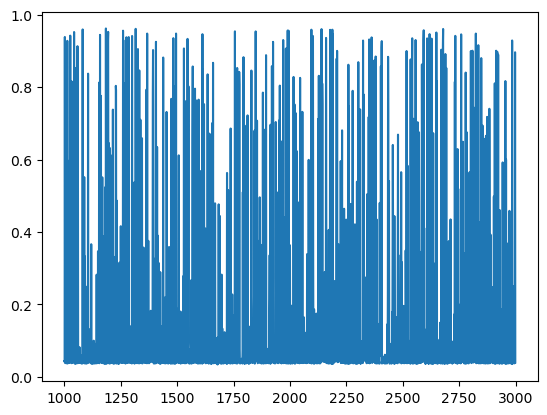

In [61]:
plt.plot(np.abs(y-final_x_probs)[1000:3000])